# Indicators calculation

In [1]:
import geopandas as gpd
import sys
sys.path.append('..')
from transport_frames.indicators import *

# Initialization

In [2]:
local_crs = 32637

The graph can be obtained by ``transport_frames.graph.get_graph_from_polygon()``

In [3]:
import pickle

with open("graph.pkl", "rb") as f:
    graph = pickle.load(f)

# Area indicators

Requires the ``settlement_points`` - points of interest to calculate distances from.

``distrcits_polygons`` - the polygons for data aggregation on different levels. Can be used for regional, district and settlement levels.



In [4]:
districts_polygons = gpd.read_file('/Users/polina/Desktop/github/transport_frames/data/Тульская_область/district.geojson')
settlement_points = gpd.read_file('/Users/polina/Desktop/github/transport_frames/data/Тульская_область/Тульская_область_region_points.geojson')

 Distance to administrative center of the region

In [5]:
capital =ox.geocode_to_gdf('N34389350',by_osmid=True)

get_distance_to_region_admin_center(capital,settlement_points,districts_polygons,graph).head()

,name,geometry,distance_to_admin_center
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",115.7150
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",130.1660
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",81.6420
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",65.2820
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",109.1135


Distance to federal roads

In [6]:
get_distance_to_federal_roads(settlement_points,districts_polygons,graph).head()

,name,geometry,distance_to_federal_roads
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",36.0405
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",6.7490
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",9.0930
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",4.8230
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",15.5010


Length of the roads 

In [7]:
get_road_length(graph, districts_polygons).head()

,name,geometry,road_length
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",785.520134
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",1213.853873
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",1074.637098
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",1740.825543
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",1042.672048


Density of the roads (km/km^2)

In [8]:
get_road_density(graph,districts_polygons).head()

,name,geometry,density
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",0.734961
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",1.022120
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",1.120421
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",1.070224
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",0.971176


Length of roads for each reg status

In [9]:
get_reg_length(graph,districts_polygons).head()

,name,geometry,length_reg_1,length_reg_2,length_reg_3
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",0.000000,284.744026,500.776108
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",107.710276,170.099209,936.044388
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",78.487690,303.526233,692.623175
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",231.395153,262.418172,1247.012218
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",56.924065,206.902682,778.845301


Drive connectivity

In [10]:
get_connectivity(settlement_points=settlement_points,
                       area_polygons=districts_polygons,
                       local_crs=local_crs,
                       graph=graph).head()

,name,geometry,connectivity
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",127.1600
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",152.1800
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",99.6300
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",105.5100
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",104.6825


Public transport connectivity

public transport graph can be obtained using ``iduedu.get_all_public_transport_graph``

In [11]:
with open("pt_graph.pkl", "rb") as f:
    pt_graph = pickle.load(f)
    
get_connectivity(settlement_points=settlement_points,
                       area_polygons=districts_polygons,
                       local_crs=local_crs,
                       graph=pt_graph).head()

,name,geometry,connectivity
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",1366.7475
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",1616.1100
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",876.5050
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",1082.1400
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",1092.9375


Number of the services inside each area polygon.


In [8]:
fuel_stations = gpd.read_file(f'/Users/polina/Desktop/github/transport_frames/data/Тульская_область/Копия fuel.geojson')

get_service_count(districts_polygons,service=fuel_stations).head()

,name,geometry,service_number
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",1
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",3
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",13
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",26
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",6


Accessibility (min) of the services inside each area polygon. If the service is found inside the area, the accessibility equals to zero. 

Based on shortest path in the graph

In [13]:
get_service_accessibility(settlement_points, graph, districts_polygons,
                            service=fuel_stations).head()

,name,geometry,service_accessibility
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",136.750
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",159.375
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",76.625
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",69.000
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",89.875


Railway road length

In [14]:
railway_roads = gpd.read_file(f'/Users/polina/Desktop/github/transport_frames/data/Тульская_область/railway.geojson')

get_railway_length(railway_roads,districts_polygons,local_crs).head()

,name,geometry,railway_length_km
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",0.000000
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",20.839681
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",83.893379
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",128.610032
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",82.777041


Number of bus routes intersecting the polygons

In [15]:
bus_routes = gpd.read_file('bus_routes.geojson')

get_bus_routes_num(districts_polygons,bus_edges=bus_routes).head()

,name,geometry,bus_routes_count
0,Арсеньевский район,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",0
1,Белевский район,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",0
2,Богородицкий район,"POLYGON ((37.86240 53.73471, 37.86404 53.72565...",1
3,Веневский район,"POLYGON ((37.86087 54.34286, 37.86265 54.34249...",0
4,Воловский район,"POLYGON ((37.73668 53.45977, 37.74516 53.45518...",0


# Territory indicators

<Axes: >

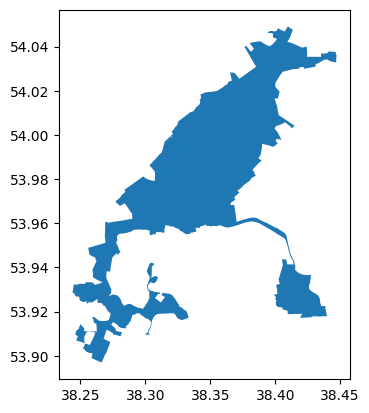

In [16]:
terr = gpd.read_file('territory.geojson')
terr.plot()

Number of the services inside territory polygon

In [24]:
get_terr_service_count(terr,
                            service=fuel_stations,
                            local_crs=local_crs).head()

,name,geometry,service_number
0,Донской,"POLYGON ((38.19874 53.93203, 38.19961 53.93585...",14


Accessibility (min) of the services inside territory polygon. If the service is found inside the area, the accessibility equals to zero. 

Based on shortest path in the graph

In [25]:
get_terr_service_accessibility(graph=graph,
                                     territory_polygon=terr,
                                     service=fuel_stations)

,name,geometry,service_accessibility
0,Донской,"POLYGON ((38.19874 53.93203, 38.19961 53.93585...",0.0


Density of the roads inside territory polygon (km/km^2) 

In [19]:
get_road_density(graph, terr)

,name,geometry,density
0,Донской,"POLYGON ((38.24402 53.92843, 38.24521 53.92841...",6.920093


Distance from center of the polygon to the administrative center of the region

In [20]:
get_terr_distance_to_region_admin_center(capital, terr, graph)

,name,geometry,distance_to_admin_center
0,Донской,"POLYGON ((38.19874 53.93203, 38.19961 53.93585...",62.653


Distance (linear) to nature objects (water objects/ nature reserves)

In [21]:
water = gpd.read_file(f'/Users/polina/Desktop/github/transport_frames/data/Тульская_область/Копия water.geojson')

get_terr_nature_distance(terr, water, local_crs)

,name,geometry,number_of_objects,objects_accessibility
0,Донской,"POLYGON ((38.24402 53.92843, 38.24521 53.92841...",31,0.0


Shortest distance to nearest district and settlement points, which are laying in intersecting districts

In [22]:
get_terr_nearest_centers(terr, graph, districts_polygons,
                               settlement_points,local_crs)

,name,geometry,to_nearest_center_km
0,Донской,"POLYGON ((38.24402 53.92843, 38.24521 53.92841...",2.242


Number of bus routes intersecting the territory

In [23]:
get_bus_routes_num(terr, bus_edges=bus_routes).head()

,name,geometry,bus_routes_count
0,Донской,"POLYGON ((38.24402 53.92843, 38.24521 53.92841...",1


Railway road length

In [24]:
get_railway_length(railway_roads,terr,local_crs).head()

,name,geometry,railway_length_km
0,Донской,"POLYGON ((38.24402 53.92843, 38.24521 53.92841...",41.102397
